# Project 4 — Counterfactual interventions: pairwise parameter coupling (Tier 2)

**Goal.** For 6 physically-motivated parameter pairs, ask whether BIND2's
response surface $\mathcal{O}(\theta_1, \theta_2)$ on a *fixed DMO halo*
is **separable** ($f(\theta_1) + g(\theta_2)$) or **coupled** (residual
$h(\theta_1, \theta_2) \neq 0$ with physical structure).

CAMELS varies these parameters along separate 1P axes, so anything the
model says about the *interior* of a 2D parameter cube is an emergent
property of what it learned — interpolation could only reproduce the
marginal 1P responses, additively.

**Pairs probed** (all on the same 20 CV halos, fiducial elsewhere):
1. $(A_{\rm SN1}, A_{\rm AGN1})$ — BH starvation
2. $(A_{\rm SN2}, A_{\rm AGN2})$ — wind-speed × AGN-burstiness
3. $(\Omega_m, \sigma_8)$ — cosmological structure formation
4. $(A_{\rm SN1}, A_{\rm SN2})$ — SN energy × SN wind speed
5. $(\Omega_b, A_{\rm AGN1})$ — baryon supply × AGN evacuation
6. $(\sigma_8, A_{\rm AGN1})$ — early-formed halos × AGN response

**Diagnostics** (replacing the variance-fraction summary, which under-
weights interactions when one marginal axis dominates):
- **Residual surface** $h(\theta_1, \theta_2)$ — divergent colormap;
  *structure* of $h$ (sign pattern, magnitude) is the headline.
- **Amplitude metric**
  $\rho(\theta_1) = \big[\max_{\theta_2} \mathcal{O} - \min_{\theta_2} \mathcal{O}\big] / \langle \mathcal{O}\rangle$.
  Constant in $\theta_1$ ⇔ separable; varying ⇔ coupled.

**Important fiducial fix.** CV halo catalogs and 1P sims store
`VariableWindSpecMomentum` (idx 14) = 2000, but the SB35 CSV fiducial is
0.  We override idx 14 = 0 in every base-params vector before sweeping —
see §1.

## 0. Setup

In [1]:
import sys
from contextlib import nullcontext
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

ROOT = Path('/mnt/home/mlee1/vdm_bind2')
sys.path.insert(0, str(ROOT))
from metrics import CHANNEL_NAMES, radial_profile
from data import NormStats
from train import FlowMatchingLit
from test_suite.pipeline import normalize_cutout, _denormalize_to_physical

plt.rcParams.update({
    'font.size': 10, 'font.family': 'serif', 'mathtext.fontset': 'cm',
    'figure.dpi': 110, 'savefig.bbox': 'tight',
})

SUITE_ROOT = Path('/mnt/home/mlee1/ceph/fm_testsuite')
RUN_DIR    = Path('/mnt/home/mlee1/ceph/fm_runs/fm_two_head')
CKPT       = RUN_DIR / 'checkpoints' / 'last.ckpt'
NORM_STATS = RUN_DIR / 'norm_stats.npz'
PARAM_META = '/mnt/home/mlee1/Sims/IllustrisTNG_extras/L50n512/SB35/SB35_param_minmax.csv'

SNAP, MASS_TAG, MODEL_NAME = 'snap_090', 'mass_threshold_1p000e13', 'fm_two_head'
BOX_SIZE, N_PIX_FULL, PATCH_PIX = 50.0, 1024, 128
N_RBINS = 32

CACHE_DIR = ROOT / 'analysis_physics_cache'
CACHE_DIR.mkdir(exist_ok=True)
FIG_DIR = ROOT / 'paper_figures'
FIG_DIR.mkdir(exist_ok=True)

PROJ4_CACHE = CACHE_DIR / f'proj4_pairs_v2_{MODEL_NAME}.npz'   # new name → invalidates buggy v1
BASE_CACHE  = CACHE_DIR / f'halo_features_{MODEL_NAME}.npz'

N_GRID    = 7
N_HALOS   = 20
N_BINS_M  = 4
N_STEPS   = 50
USE_AMP   = True
RNG_SEED  = 17

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device, '  Checkpoint:', CKPT.name)

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/mnt/sw/nix/store/6qvrglgqdpwhbw9zv2nh07fpd7a4wq31-py-torchvision-0.15.2/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Device: cuda   Checkpoint: last.ckpt


## 1. Parameter metadata + fiducial override

We pull canonical fiducial values from the SB35 CSV; the *only* index
where the CV halo catalogs disagree with the CSV is
`VariableWindSpecMomentum` (idx 14, stored=2000, true fiducial=0).  We
encode this as a single override dict so we can apply it to every base
vector before sweeping.

In [2]:
param_meta = pd.read_csv(PARAM_META)
PARAM_NAMES = {i: n for i, n in enumerate(param_meta['ParamName'])}
PARAM_LOG   = {i: bool(v) for i, v in enumerate(param_meta['LogFlag'])}
PARAM_FID   = {i: float(v) for i, v in enumerate(param_meta['FiducialVal'])}
PARAM_MIN   = {i: float(v) for i, v in enumerate(param_meta['MinVal'])}
PARAM_MAX   = {i: float(v) for i, v in enumerate(param_meta['MaxVal'])}

FIDUCIAL_OVERRIDES = {14: 0.0}    # VariableWindSpecMomentum (CV-stored=2000, true=0)

def apply_fiducial_overrides(p: np.ndarray) -> np.ndarray:
    out = p.astype(np.float32).copy()
    for idx, val in FIDUCIAL_OVERRIDES.items():
        out[idx] = val
    return out

def param_grid(idx, n=N_GRID):
    lo, hi = PARAM_MIN[idx], PARAM_MAX[idx]
    return np.geomspace(lo, hi, n) if PARAM_LOG[idx] else np.linspace(lo, hi, n)

for idx in (14,):
    print(f'Override idx {idx} ({PARAM_NAMES[idx]}): CV-stored != CSV-fiducial → set to {FIDUCIAL_OVERRIDES[idx]}')

Override idx 14 (VariableWindSpecMomentum): CV-stored != CSV-fiducial → set to 0.0


## 2. Pair definitions

Each pair specifies the two SB35 indices to sweep, plus the single
**physically diagnostic observable** for that pair (the one whose
expected coupling structure has the clearest physical interpretation).
All four observables are computed for every pair — the diagnostic one is
what the headline figure plots.

In [3]:
def _pidx(name): return int(param_meta.index[param_meta['ParamName'] == name][0])

PAIRS = [
    dict(name='ASN1_x_AAGN1',
         x=_pidx('WindEnergyIn1e51erg'),     y=_pidx('RadioFeedbackFactor'),
         x_label=r'$A_{\rm SN1}$',           y_label=r'$A_{\rm AGN1}$',
         diag_obs='sigma_gas_central',
         physics='BH starvation: high SN heats gas before BH accretion → AGN response weakens'),
    dict(name='ASN2_x_AAGN2',
         x=_pidx('VariableWindVelFactor'),   y=_pidx('RadioFeedbackReiorientationFactor'),
         x_label=r'$A_{\rm SN2}$',           y_label=r'$A_{\rm AGN2}$',
         diag_obs='sigma_gas_central',
         physics='Faster winds + bursty AGN: similar starvation chain through wind-driven gas removal'),
    dict(name='Om_x_s8',
         x=_pidx('Omega0'),                   y=_pidx('sigma8'),
         x_label=r'$\Omega_m$',               y_label=r'$\sigma_8$',
         diag_obs='M_star',
         physics='Structure formation: σ8 controls collapse epoch, Ωm halo abundance — couple in M_★'),
    dict(name='ASN1_x_ASN2',
         x=_pidx('WindEnergyIn1e51erg'),      y=_pidx('VariableWindVelFactor'),
         x_label=r'$A_{\rm SN1}$',            y_label=r'$A_{\rm SN2}$',
         diag_obs='sigma_gas_central',
         physics='SN energy × wind speed: physically multiplicative (energy ∝ velocity²)'),
    dict(name='Ob_x_AAGN1',
         x=_pidx('OmegaBaryon'),              y=_pidx('RadioFeedbackFactor'),
         x_label=r'$\Omega_b$',               y_label=r'$A_{\rm AGN1}$',
         diag_obs='f_gas',
         physics='Baryon supply × AGN evacuation: more Ωb → more gas to evict, AGN response amplified'),
    dict(name='s8_x_AAGN1',
         x=_pidx('sigma8'),                   y=_pidx('RadioFeedbackFactor'),
         x_label=r'$\sigma_8$',               y_label=r'$A_{\rm AGN1}$',
         diag_obs='M_star',
         physics='Earlier-formed halos (high σ8) → more time for BH growth → AGN response strengthens'),
]

# Per pair: build grids and a (49, 35) param-grid template (filled with fid; pair entries vary)
for p in PAIRS:
    p['x_grid'] = param_grid(p['x'])
    p['y_grid'] = param_grid(p['y'])
    p['short']  = p['name']

for p in PAIRS:
    print(f"  {p['name']:18s}  x=idx {p['x']:2d} ({PARAM_NAMES[p['x']][:25]:25s}) range [{PARAM_MIN[p['x']]:6.3g}, {PARAM_MAX[p['x']]:6.3g}]")
    print(f"  {'':18s}  y=idx {p['y']:2d} ({PARAM_NAMES[p['y']][:25]:25s}) range [{PARAM_MIN[p['y']]:6.3g}, {PARAM_MAX[p['y']]:6.3g}]")
    print(f"  {'':18s}  diag obs: {p['diag_obs']}")

  ASN1_x_AAGN1        x=idx  2 (WindEnergyIn1e51erg      ) range [   0.9,   14.4]
                      y=idx  3 (RadioFeedbackFactor      ) range [  0.25,      4]
                      diag obs: sigma_gas_central
  ASN2_x_AAGN2        x=idx  4 (VariableWindVelFactor    ) range [   3.7,   14.8]
                      y=idx  5 (RadioFeedbackReiorientati) range [    10,     40]
                      diag obs: sigma_gas_central
  Om_x_s8             x=idx  0 (Omega0                   ) range [   0.1,    0.5]
                      y=idx  1 (sigma8                   ) range [   0.6,      1]
                      diag obs: M_star
  ASN1_x_ASN2         x=idx  2 (WindEnergyIn1e51erg      ) range [   0.9,   14.4]
                      y=idx  4 (VariableWindVelFactor    ) range [   3.7,   14.8]
                      diag obs: sigma_gas_central
  Ob_x_AAGN1          x=idx  6 (OmegaBaryon              ) range [ 0.029,  0.069]
                      y=idx  3 (RadioFeedbackFactor      ) range [  0.25,

## 3. Halo selection: same 20 CV halos as before (mass-stratified)

In [4]:
_base = np.load(BASE_CACHE, allow_pickle=False)
_cv = _base['suite'] == 'CV'
cv_logM   = _base['logM'][_cv]
cv_simid  = _base['sim_id'][_cv]

rng = np.random.default_rng(RNG_SEED)
edges = np.quantile(cv_logM, np.linspace(0, 1, N_BINS_M + 1))
edges[0] -= 1e-6; edges[-1] += 1e-6
bin_idx = np.digitize(cv_logM, edges) - 1
per_bin = N_HALOS // N_BINS_M

selected_local = []
for b in range(N_BINS_M):
    cand = np.where(bin_idx == b)[0]
    pick = rng.choice(cand, size=min(per_bin, len(cand)), replace=False)
    selected_local.append(pick)
selected_local = np.concatenate(selected_local)

selected_meta = []
for li in selected_local:
    sid = str(cv_simid[li])
    rows_in_sim = np.where(cv_simid == sid)[0]
    pos_in_sim = int(np.where(rows_in_sim == li)[0][0])
    selected_meta.append(dict(sim_id=sid, pos_in_sim=pos_in_sim,
                              logM=float(cv_logM[li]), mass_bin=int(bin_idx[li])))
selected_df = pd.DataFrame(selected_meta).sort_values(['sim_id', 'pos_in_sim']).reset_index(drop=True)
print(f'Selected {len(selected_df)} halos across {selected_df["sim_id"].nunique()} CV sims')
print('Mass-bin counts:', selected_df['mass_bin'].value_counts().to_dict())
selected_df.head()

Selected 20 halos across 16 CV sims
Mass-bin counts: {3: 5, 2: 5, 0: 5, 1: 5}


,sim_id,pos_in_sim,logM,mass_bin
0,sim_0,14,13.604252,3
1,sim_0,22,13.443454,2
2,sim_1,18,13.489618,2
3,sim_11,53,13.060765,0
4,sim_12,50,13.016064,0


## 4. Generation: 6 pairs × 20 halos × 49 cells

Per (pair, halo) we batch a single `fm.sample` call of size 49 with the
same (cond, large_scale) replicated and 49 different param vectors.  The
base params for every cell are the CV-stored values *with the idx-14
fiducial fix applied*; only the pair indices `(p['x'], p['y'])` are
varied.

Patches: shape `(N_PAIRS, N_HALOS, 49, 3, 128, 128)` ≈ 760 MB; cached to
[analysis_physics_cache/proj4_pairs_v2_*.npz](analysis_physics_cache/).

In [5]:
def load_model():
    norm_stats = NormStats.load(NORM_STATS)
    lit = FlowMatchingLit.load_from_checkpoint(CKPT, map_location=device)
    lit.eval(); lit.to(device)
    return norm_stats, lit.fm

def _load_sim_arrays(sim_id: str):
    base = SUITE_ROOT / 'CV' / sim_id / SNAP
    cat  = np.load(base / MASS_TAG / 'halo_catalog.npz')
    cuts = np.load(base / MASS_TAG / 'halo_cutouts.npz')
    return cat, cuts

def make_pair_param_grid(base_params: np.ndarray, ix: int, iy: int,
                          x_grid: np.ndarray, y_grid: np.ndarray) -> np.ndarray:
    """(N_GRID*N_GRID, 35); cell k = i_y * N_GRID + i_x."""
    G = np.tile(base_params.astype(np.float32), (N_GRID * N_GRID, 1))
    for iyv, yv in enumerate(y_grid):
        for ixv, xv in enumerate(x_grid):
            k = iyv * N_GRID + ixv
            G[k, ix] = xv
            G[k, iy] = yv
    return G

def _normalize_grid_params(grid: np.ndarray, ns) -> np.ndarray:
    """Apply the same per-param min/max + log scaling as normalize_cutout."""
    p = grid.astype(np.float64)
    p = np.where(ns.param_log_flag == 1, np.log10(np.maximum(p, 1e-30)), p)
    rang = ns.param_max - ns.param_min
    return ((p - ns.param_min) / (rang + 1e-8)).astype(np.float32)

def generate_pair_for_halo(fm, ns, hc, base_params, pair, n_steps):
    grid = make_pair_param_grid(base_params, pair['x'], pair['y'], pair['x_grid'], pair['y_grid'])
    cond_n, ls_n, _ = normalize_cutout(hc, ns, grid[0])
    params_n = _normalize_grid_params(grid, ns)
    K = len(grid)
    cond_t = torch.from_numpy(cond_n[None].repeat(K, axis=0)).to(device)
    ls_t   = torch.from_numpy(ls_n[None].repeat(K, axis=0)).to(device)
    p_t    = torch.from_numpy(params_n).to(device)
    amp_ctx = (torch.amp.autocast(device_type='cuda', dtype=torch.bfloat16)
               if USE_AMP and device.type == 'cuda' else nullcontext())
    with torch.no_grad(), amp_ctx:
        gen = fm.sample(cond_t, ls_t, p_t, n_steps=n_steps)
    return _denormalize_to_physical(gen.float().cpu().numpy().astype(np.float32), ns)

def build_pairs_cache(force=False):
    if PROJ4_CACHE.exists() and not force:
        print('Loading', PROJ4_CACHE)
        z = np.load(PROJ4_CACHE, allow_pickle=False)
        return {k: z[k] for k in z.files}

    norm_stats, fm = load_model()
    n_pairs, n_h = len(PAIRS), len(selected_df)
    patches_all = np.zeros((n_pairs, n_h, N_GRID * N_GRID, 3, PATCH_PIX, PATCH_PIX), dtype=np.float32)
    base_params_per_halo = []

    last_sid = None
    for hi, rec in tqdm(list(selected_df.iterrows()), desc='Halos'):
        sid = rec['sim_id']
        if sid != last_sid:
            cat, cuts = _load_sim_arrays(sid)
            last_sid = sid
        pos = int(rec['pos_in_sim'])
        hc = {'condition': cuts['condition'][pos], 'large_scale': cuts['large_scale'][pos]}
        # apply the fiducial override to every base vector before sweeping
        base_p = apply_fiducial_overrides(np.asarray(cat['params'][pos], dtype=np.float32))
        base_params_per_halo.append(base_p.copy())

        for pi, pair in enumerate(PAIRS):
            torch.manual_seed(RNG_SEED + hi * 100 + pi)
            patches_all[pi, hi] = generate_pair_for_halo(fm, norm_stats, hc, base_p, pair, n_steps=N_STEPS)

    out = dict(
        patches=patches_all,
        pair_names=np.asarray([p['name'] for p in PAIRS]),
        pair_x_idx=np.asarray([p['x'] for p in PAIRS], dtype=np.int32),
        pair_y_idx=np.asarray([p['y'] for p in PAIRS], dtype=np.int32),
        pair_x_grids=np.stack([p['x_grid'] for p in PAIRS]).astype(np.float32),
        pair_y_grids=np.stack([p['y_grid'] for p in PAIRS]).astype(np.float32),
        sim_id=np.asarray(selected_df['sim_id'].values, dtype='U16'),
        pos_in_sim=np.asarray(selected_df['pos_in_sim'].values, dtype=np.int32),
        logM=np.asarray(selected_df['logM'].values, dtype=np.float32),
        mass_bin=np.asarray(selected_df['mass_bin'].values, dtype=np.int32),
        base_params=np.stack(base_params_per_halo).astype(np.float32),
    )
    np.savez_compressed(PROJ4_CACHE, **out)
    print('Wrote', PROJ4_CACHE, f'  ({PROJ4_CACHE.stat().st_size/1e6:.0f} MB)')
    return out

proj4 = build_pairs_cache()
print('patches shape:', proj4['patches'].shape, '(pair, halo, grid, channel, H, W)')

Loading /mnt/home/mlee1/vdm_bind2/analysis_physics_cache/proj4_pairs_v2_fm_two_head.npz
patches shape: (6, 20, 49, 3, 128, 128) (pair, halo, grid, channel, H, W)


## 5. Observables (4 scalars per patch)

Same set as before: $M_\star$, central gas density, $f_{\rm gas}$,
stellar compactness.

In [6]:
_yy, _xx = np.mgrid[0:PATCH_PIX, 0:PATCH_PIX] - PATCH_PIX / 2
_rr = np.sqrt(_xx ** 2 + _yy ** 2)
_bins_pix = np.linspace(0, PATCH_PIX / 2, N_RBINS + 1)
_bin_counts = np.array([((_rr >= _bins_pix[k]) & (_rr < _bins_pix[k+1])).sum()
                         for k in range(N_RBINS)], dtype=np.float64)
INNER_BINS = 8
CENTRAL_PIX = 16

def _radial(maps2d):
    out = np.empty((len(maps2d), N_RBINS))
    for i, m in enumerate(maps2d):
        _, p = radial_profile(m, n_bins=N_RBINS)
        out[i] = p
    return out

OBS_NAMES = ['M_star', 'sigma_gas_central', 'f_gas', 'compact_star']
OBS_LABELS = {
    'M_star':            r'$M_\star$',
    'sigma_gas_central': r'$\langle\Sigma_{\rm gas}\rangle_{\rm central}$',
    'f_gas':             r'$f_{\rm gas}$',
    'compact_star':      r'$M_\star(<0.25R)/M_\star$',
}

def compute_obs(patches_NCHW: np.ndarray) -> dict:
    dm, gas, star = patches_NCHW[:, 0], patches_NCHW[:, 1], patches_NCHW[:, 2]
    M_DM   = dm.sum(axis=(1, 2))
    M_gas  = gas.sum(axis=(1, 2))
    M_star = star.sum(axis=(1, 2))
    M_tot  = M_DM + M_gas + M_star + 1e-30
    half = PATCH_PIX // 2
    s, e = half - CENTRAL_PIX // 2, half + CENTRAL_PIX // 2
    sigma_gas_central = gas[:, s:e, s:e].mean(axis=(1, 2))
    p_star = _radial(star)
    enc_star = (p_star * _bin_counts).cumsum(axis=1)
    compact_star = enc_star[:, INNER_BINS - 1] / (enc_star[:, -1] + 1e-30)
    return dict(
        M_star=M_star, sigma_gas_central=sigma_gas_central,
        f_gas=M_gas / M_tot, compact_star=compact_star,
    )

n_pairs, n_halos, n_cells = proj4['patches'].shape[:3]
OBS_CUBES = {n: np.zeros((n_pairs, n_halos, N_GRID, N_GRID), dtype=np.float64) for n in OBS_NAMES}
for pi in tqdm(range(n_pairs), desc='Pairs'):
    for hi in range(n_halos):
        feat = compute_obs(proj4['patches'][pi, hi])
        for n in OBS_NAMES:
            OBS_CUBES[n][pi, hi] = feat[n].reshape(N_GRID, N_GRID)   # (y, x)
print('OBS_CUBES shapes:', {n: c.shape for n, c in OBS_CUBES.items()}, '(pair, halo, y, x)')

Pairs:   0%|          | 0/6 [00:00<?, ?it/s]

OBS_CUBES shapes: {'M_star': (6, 20, 7, 7), 'sigma_gas_central': (6, 20, 7, 7), 'f_gas': (6, 20, 7, 7), 'compact_star': (6, 20, 7, 7)} (pair, halo, y, x)


## 6. ANOVA + amplitude metrics, per pair × observable

Two diagnostics, both better than the variance fraction:

1. **Residual surface** $h(\theta_x, \theta_y) = \mathcal{O} - \bar{\mathcal{O}} - f(\theta_x) - g(\theta_y)$.  Plotted on a divergent colormap centred at 0; structure of $h$ is the headline.
2. **Amplitude metric**: response amplitude of $\theta_y$ as a function of $\theta_x$,
$$\rho(\theta_x) = \frac{\max_{\theta_y} \mathcal{O}(\theta_x, \theta_y) - \min_{\theta_y} \mathcal{O}(\theta_x, \theta_y)}{\langle\mathcal{O}\rangle}.$$
Constant in $\theta_x$ ⇔ separable.  Decreasing with $\theta_x$ in the BH-starvation example ⇔ coupled.

In [7]:
def anova2d(M):
    """Decompose surface M[y, x] into grand mean, marginals f(x) g(y), interaction h(y, x)."""
    grand = M.mean()
    g_eff = M.mean(axis=1) - grand     # depends on y
    f_eff = M.mean(axis=0) - grand     # depends on x
    h_eff = M - grand - g_eff[:, None] - f_eff[None, :]
    return dict(grand=grand, f=f_eff, g=g_eff, h=h_eff,
                sigma2_tot=M.var(), sigma2_f=(f_eff**2).mean(),
                sigma2_g=(g_eff**2).mean(), sigma2_h=(h_eff**2).mean())

def amplitude_along_x(M):
    """ρ(θ_x) = (max - min over y) / |mean|, length N_GRID along the x axis."""
    span = M.max(axis=0) - M.min(axis=0)
    return span / (np.abs(M.mean()) + 1e-30)

def amplitude_along_y(M):
    span = M.max(axis=1) - M.min(axis=1)
    return span / (np.abs(M.mean()) + 1e-30)

ANOVA = {}                  # ANOVA[pair_name][obs] = anova2d output + surface
AMP   = {}                  # AMP[pair_name][obs]   = (rho_x, rho_y)
for pi, pair in enumerate(PAIRS):
    ANOVA[pair['name']] = {}
    AMP[pair['name']]   = {}
    for n in OBS_NAMES:
        surf = OBS_CUBES[n][pi].mean(axis=0)            # mean over halos → (y, x)
        a = anova2d(surf)
        ANOVA[pair['name']][n] = dict(surface=surf, **a)
        AMP[pair['name']][n]   = (amplitude_along_x(surf), amplitude_along_y(surf))

rows = []
for pair in PAIRS:
    for n in OBS_NAMES:
        a = ANOVA[pair['name']][n]
        rho_x, rho_y = AMP[pair['name']][n]
        rows.append(dict(
            pair=pair['name'], obs=n, diag=(n == pair['diag_obs']),
            interaction_frac=a['sigma2_h'] / (a['sigma2_tot'] + 1e-30),
            h_amplitude_relmean=np.abs(a['h']).max() / (np.abs(a['grand']) + 1e-30),
            rho_y_at_xmin=float(rho_y[0]),  rho_y_at_xmax=float(rho_y[-1]),
            rho_y_ratio=float(rho_y[-1] / (rho_y[0] + 1e-30)),
        ))
summary = pd.DataFrame(rows)
print('Summary (rows where diag=True are the headline observable per pair):')
summary.round(3)

Summary (rows where diag=True are the headline observable per pair):


,pair,obs,diag,interaction_frac,h_amplitude_relmean,rho_y_at_xmin,rho_y_at_xmax,rho_y_ratio
0,ASN1_x_AAGN1,M_star,False,0.003,0.065,1.487,1.338,0.900
1,ASN1_x_AAGN1,sigma_gas_central,True,0.010,0.057,0.371,0.478,1.289
2,ASN1_x_AAGN1,f_gas,False,0.017,0.007,0.048,0.052,1.092
3,ASN1_x_AAGN1,compact_star,False,0.021,0.026,0.220,0.286,1.301
4,ASN2_x_AAGN2,M_star,False,0.002,0.059,1.653,1.720,1.041
5,ASN2_x_AAGN2,sigma_gas_central,True,0.022,0.065,0.270,0.380,1.411
6,ASN2_x_AAGN2,f_gas,False,0.010,0.006,0.060,0.067,1.126
7,ASN2_x_AAGN2,compact_star,False,0.135,0.047,0.147,0.095,0.648
8,Om_x_s8,M_star,True,0.001,0.086,1.968,1.894,0.962
9,Om_x_s8,sigma_gas_central,False,0.001,0.046,1.203,1.139,0.946


## 7. Headline figure: residual surfaces $h(\theta_x, \theta_y)$

2×3 grid, one panel per pair, showing the residual surface for that
pair's diagnostic observable.  Divergent colormap centred at 0 — the
*structure* of $h$ is what we read.  A featureless $h$ ⇔ separable
response; a coherent sign pattern ⇔ learned coupling.

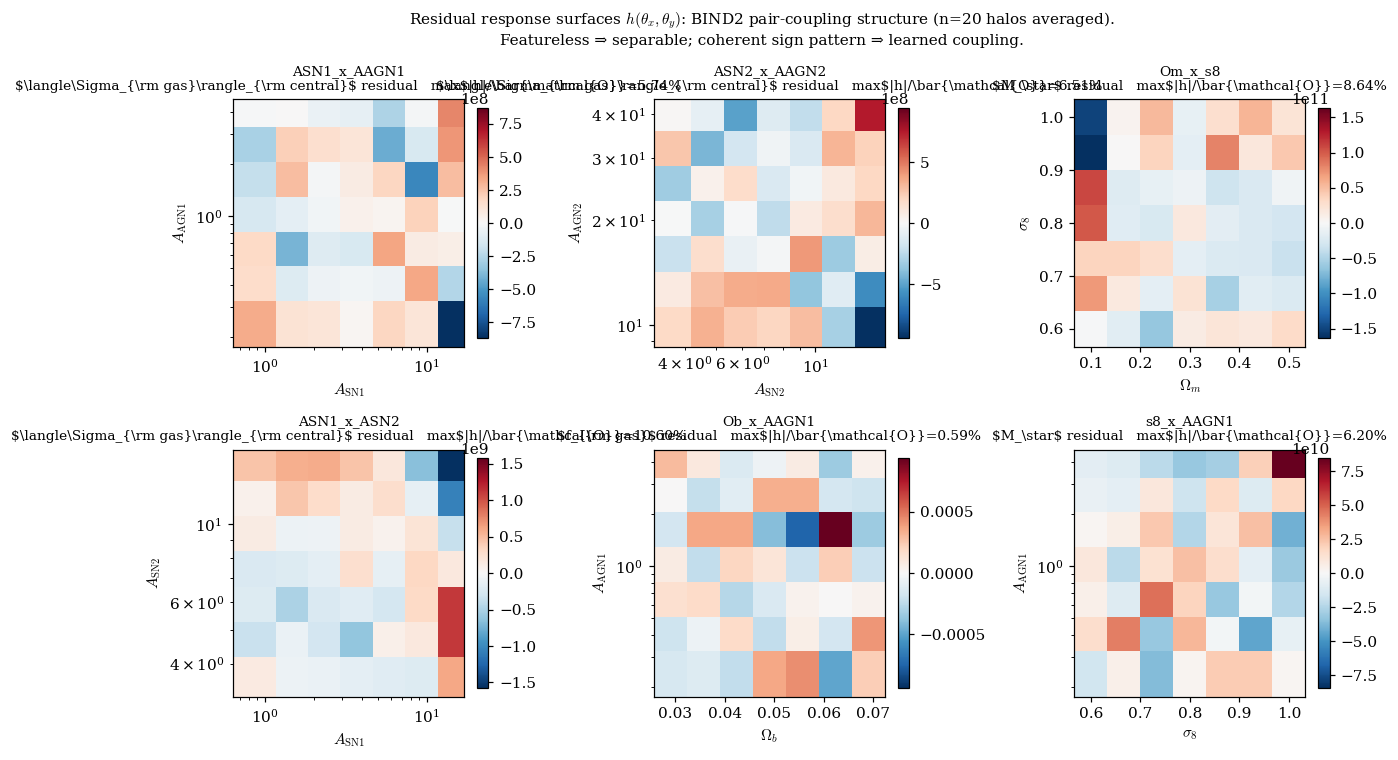

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.0))
for ax, pair in zip(axes.flat, PAIRS):
    n = pair['diag_obs']
    a = ANOVA[pair['name']][n]
    h = a['h']                                          # (y, x)
    vmax = max(np.abs(h).max(), 1e-30)
    im = ax.pcolormesh(pair['x_grid'], pair['y_grid'], h,
                        shading='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    if PARAM_LOG[pair['x']]: ax.set_xscale('log')
    if PARAM_LOG[pair['y']]: ax.set_yscale('log')
    ax.set_xlabel(pair['x_label'])
    ax.set_ylabel(pair['y_label'])
    rel_amp = np.abs(h).max() / (np.abs(a['grand']) + 1e-30)
    ax.set_title(f"{pair['name']}\n{OBS_LABELS[n]} residual   max$|h|/\\bar{{\\mathcal{{O}}}}={rel_amp:.2%}",
                  fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.045)

fig.suptitle('Residual response surfaces $h(\\theta_x, \\theta_y)$: BIND2 pair-coupling structure (n=20 halos averaged).\n'
              'Featureless ⇒ separable; coherent sign pattern ⇒ learned coupling.', fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / 'proj4_residual_surfaces.png', dpi=150)
fig.savefig(FIG_DIR / 'proj4_residual_surfaces.pdf')
plt.show()

## 8. Amplitude-metric figure

For each pair, plot $\rho_y(\theta_x)$ — the relative response amplitude
of $\theta_y$ as the conditioning variable $\theta_x$ is varied.  Flat
lines mean the pair is separable for the diagnostic observable.
Decreasing curves are the BH-starvation-style signature: the response to
$\theta_y$ weakens at high $\theta_x$.

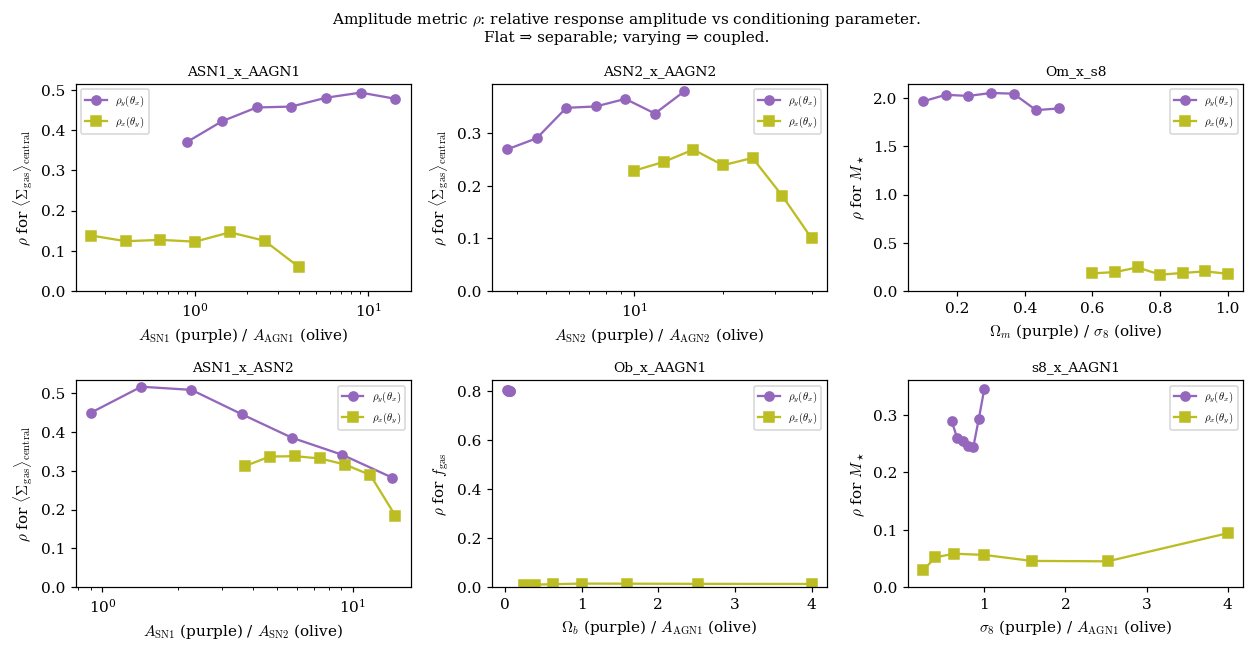

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.0))
for ax, pair in zip(axes.flat, PAIRS):
    n = pair['diag_obs']
    rho_x, rho_y = AMP[pair['name']][n]
    # rho_y is the response-to-θ_y amplitude as a function of θ_x → length N_GRID along x
    ax.plot(pair['x_grid'], rho_y, '-o', color='tab:purple', label=fr'$\rho_{{y}}(\theta_x)$')
    ax.plot(pair['y_grid'], rho_x, '-s', color='tab:olive', label=fr'$\rho_{{x}}(\theta_y)$')
    if PARAM_LOG[pair['x']]: ax.set_xscale('log')
    ax.set_xlabel(f"{pair['x_label']} (purple) / {pair['y_label']} (olive)")
    ax.set_ylabel(rf'$\rho$ for {OBS_LABELS[n]}')
    ax.set_title(pair['name'], fontsize=9)
    ax.legend(fontsize=7, loc='best')
    ax.set_ylim(bottom=0)

fig.suptitle('Amplitude metric $\\rho$: relative response amplitude vs conditioning parameter.\n'
              'Flat ⇒ separable; varying ⇒ coupled.', fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR / 'proj4_amplitude_metric.png', dpi=150)
fig.savefig(FIG_DIR / 'proj4_amplitude_metric.pdf')
plt.show()

## 9. Pre-registered tests, per pair

For each pair, on its diagnostic observable:
1. **Coupling exists.** $\max|h|/\bar{\mathcal{O}} \geq 0.02$ (2% of mean).
2. **Coupling has structure.** $\sigma^2_h / \sigma^2_{\rm tot} \geq 0.02$ (residual is not isotropic noise).
3. **Amplitude metric is non-flat.** $|\rho_y(\theta_{x,\max}) - \rho_y(\theta_{x,\min})| / \langle \rho_y\rangle \geq 0.30$ (30%+ relative change in conditioning sensitivity).

Pair passes if all three hold.

In [11]:
test_rows = []
for pair in PAIRS:
    n = pair['diag_obs']
    a = ANOVA[pair['name']][n]
    rho_x, rho_y = AMP[pair['name']][n]
    rel_h    = float(np.abs(a['h']).max() / (np.abs(a['grand']) + 1e-30))
    frac_h   = float(a['sigma2_h'] / (a['sigma2_tot'] + 1e-30))
    rho_mean = float(np.mean(rho_y) + 1e-30)
    rho_dev  = float(np.abs(rho_y[-1] - rho_y[0]) / rho_mean)
    test_rows.append(dict(
        pair=pair['name'],
        diag_obs=n,
        rel_h_amp=rel_h,           # max|h|/mean(O)
        interaction_frac=frac_h,    # σ²_h / σ²_tot
        rho_y_swing=rho_dev,        # |ρ_y(xmax) - ρ_y(xmin)| / <ρ_y>
        pass_rel_h=bool(rel_h >= 0.02),
        pass_frac_h=bool(frac_h >= 0.02),
        pass_rho_swing=bool(rho_dev >= 0.30),
    ))
tests = pd.DataFrame(test_rows)
tests['pass_all'] = tests['pass_rel_h'] & tests['pass_frac_h'] & tests['pass_rho_swing']
tests.round(3)

,pair,diag_obs,rel_h_amp,interaction_frac,rho_y_swing,pass_rel_h,pass_frac_h,pass_rho_swing,pass_all
0,ASN1_x_AAGN1,sigma_gas_central,0.057,0.010,0.237,True,False,False,False
1,ASN2_x_AAGN2,sigma_gas_central,0.065,0.022,0.331,True,True,True,True
2,Om_x_s8,M_star,0.086,0.001,0.037,True,False,False,False
3,ASN1_x_ASN2,sigma_gas_central,0.106,0.030,0.401,True,True,True,True
4,Ob_x_AAGN1,f_gas,0.006,0.000,0.005,False,False,False,False
5,s8_x_AAGN1,M_star,0.062,0.041,0.202,True,True,False,False


## 10. Interpretation cheatsheet

Per pair (read each row of the tests table together with the corresponding
panel of the residual figure and amplitude figure):

- **All three pass + residual has the predicted sign pattern**
  → BIND has internalised this physical coupling.  Strong methods-paper
  result for this pair.
- **Tests pass but residual sign is wrong** → BIND has *some* coupling but
  it is unphysical; investigate possible training-data correlation
  shortcut through unintervened parameters.
- **rel_h passes, frac_h fails** → response is dominated by one marginal
  axis but a non-trivial residual exists (the headline 2×2-figure trap
  from the previous run).  Read the residual surface directly.
- **All three fail** → BIND is separable across this pair.  Either it
  really has not learned the coupling, or 20 halos do not have power to
  detect it.  Re-run with 50 halos before drawing the strong conclusion.

**Specific physics expectations for sign-of-h:**

| Pair | Expected high-x, high-y residual sign |
|---|---|
| (A_SN1, A_AGN1) | $h > 0$ in (high SN, high AGN) — BH starved, gas not removed |
| (A_SN2, A_AGN2) | $h > 0$ in (high A_SN2, high A_AGN2) — same chain |
| (Ωm, σ8)        | $h > 0$ in (high Ωm, high σ8) — superlinear M_★ growth |
| (A_SN1, A_SN2)  | $h < 0$ in (high, high) — multiplicative wind energy ⇒ Σ_gas drops faster |
| (Ωb, A_AGN1)    | $h < 0$ in (high Ωb, high AGN) — more gas to evict, AGN-amplified loss |
| (σ8, A_AGN1)    | $h < 0$ in (high σ8, high AGN) — older halos more responsive to AGN |

These are *approximate* — happy to refine.